Cargado Decision Tree: window_size=30, clipping=115
Cargado NegBinomial: window_size=30, clipping=115
Cargado Random Forest: window_size=30, clipping=115
Cargado SVR: window_size=30, clipping=115


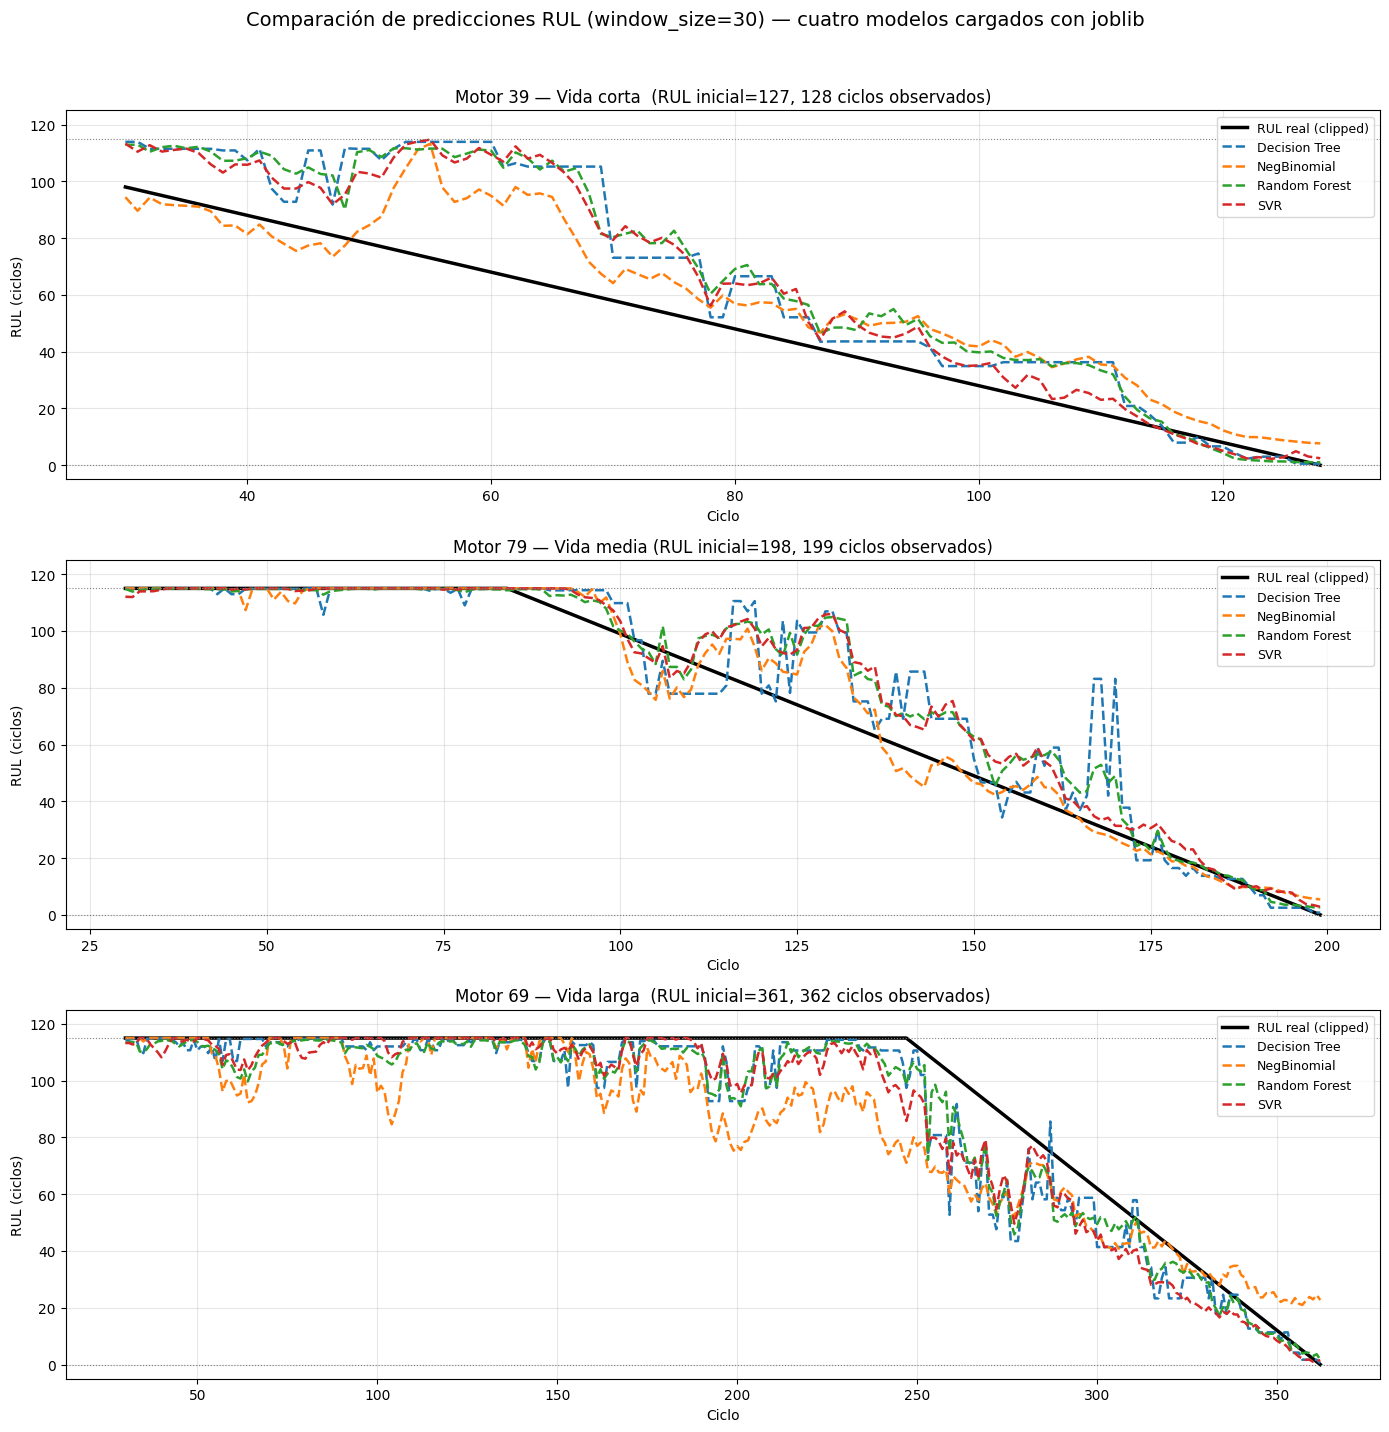

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------------------------------------------------------------
# 1. Cargar los cuatro modelos
# ----------------------------------------------------------------------
model_paths = {
    'Decision Tree': 'outputs/production/models/DecisionTreeModel_A_30w_10pc_20260510_1148.pkl',
    'NegBinomial':   'outputs/production/models/NegativeBinomialPiecewise_B_30w_20pc_20260509_1811.pkl',
    'Random Forest': 'outputs/production/models/RandomForestModel_A_30w_20pc_20260510_2159.pkl',
    'SVR':           'outputs/production/models/SVRModel_A_30w_10pc_20260510_2152.pkl',
}

models = {}
for name, path in model_paths.items():
    models[name] = joblib.load(path)
    print(f"Cargado {name}: window_size={models[name].window_size}, clipping={models[name].clipping_threshold}")

# Tomamos los parámetros del primer modelo (todos iguales)
any_model = list(models.values())[0]
window_size = any_model.window_size          # 30
clipping = any_model.clipping_threshold      # 115 o 120

# ----------------------------------------------------------------------
# 2. Motores a visualizar
# ----------------------------------------------------------------------
motores = [
    (39, 'Vida corta  (RUL inicial=127, 128 ciclos observados)'),
    (79, 'Vida media (RUL inicial=198, 199 ciclos observados)'),
    (69, 'Vida larga  (RUL inicial=361, 362 ciclos observados)'),
]

# ----------------------------------------------------------------------
# 3. Crear figura con 3 subgráficos
# ----------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for ax, (motor_id, titulo) in zip(axes, motores):
    # Cargar datos del motor
    df_m = pd.read_csv(f'data/clean/data_motor_{motor_id}.csv')
    df_m.insert(0, 'unit_number', motor_id)   # necesario para el pipeline
    X_m = df_m.drop(columns=['RUL'])
    
    # Obtener el vector de tiempos (t_stop) usando cualquier modelo (todos dan el mismo)
    _, _, t_stop, _, _ = any_model.pipeline_.transform(X_m)
    
    # RUL real recortada y clippeada (igual que en el código original)
    rul_real = np.minimum(df_m['RUL'].values[window_size - 1:], clipping)
    
    # Graficar RUL real
    ax.plot(t_stop, rul_real, label='RUL real (clipped)', color='black', linewidth=2.5)
    
    # Graficar predicción de cada modelo
    for name, model in models.items():
        rul_pred = model.predict(X_m, return_mode='all')
        ax.plot(t_stop, rul_pred, label=name, linestyle='--', linewidth=1.8)
    
    # Decoraciones
    ax.set_title(f'Motor {motor_id} — {titulo}', fontsize=12)
    ax.set_xlabel('Ciclo')
    ax.set_ylabel('RUL (ciclos)')
    ax.set_ylim(-5, clipping + 10)
    ax.axhline(y=0, color='gray', linewidth=0.8, linestyle=':')
    ax.axhline(y=clipping, color='gray', linewidth=0.8, linestyle=':')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparación de predicciones RUL (window_size=30) — cuatro modelos cargados con joblib',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [2]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
import joblib

# ----------------------------------------------------------------------
# 1. Cargar los cuatro modelos (todos con window_size=30)
# ----------------------------------------------------------------------
model_paths = {
    'Decision Tree': 'outputs/production/models/DecisionTreeModel_A_30w_10pc_20260510_1148.pkl',
    'NegBinomial':   'outputs/production/models/NegativeBinomialPiecewise_B_30w_20pc_20260509_1811.pkl',
    'Random Forest': 'outputs/production/models/RandomForestModel_A_30w_20pc_20260510_2159.pkl',
    'SVR':           'outputs/production/models/SVRModel_A_30w_10pc_20260510_2152.pkl',
}

models = {}
for name, path in model_paths.items():
    models[name] = joblib.load(path)
    print(f"Cargado {name}: window_size={models[name].window_size}, clipping={models[name].clipping_threshold}")

# Tomamos parámetros comunes (todos iguales)
any_model = list(models.values())[0]
window_size = any_model.window_size          # 30
clipping = any_model.clipping_threshold      # 115 o 120

# ----------------------------------------------------------------------
# 2. Motores a visualizar
# ----------------------------------------------------------------------
motores = [
    (39, 'Vida corta  (RUL inicial=127, 128 ciclos observados)'),
    (79, 'Vida media (RUL inicial=198, 199 ciclos observados)'),
    (69, 'Vida larga  (RUL inicial=361, 362 ciclos observados)'),
]

# ----------------------------------------------------------------------
# 3. Crear figura con 3 subplots (uno por motor)
# ----------------------------------------------------------------------
fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    subplot_titles=[f'Motor {motor_id} — {titulo}' for motor_id, titulo in motores],
    vertical_spacing=0.1
)

# Colores consistentes
colors = {
    'RUL real': 'black',
    'Decision Tree': 'blue',
    'NegBinomial': 'green',
    'Random Forest': 'red',
    'SVR': 'purple'
}

# ----------------------------------------------------------------------
# 4. Añadir trazas: RUL real (una sola entrada en leyenda)
# ----------------------------------------------------------------------
for row, (motor_id, _) in enumerate(motores, start=1):
    df_m = pd.read_csv(f'data/clean/data_motor_{motor_id}.csv')
    df_m.insert(0, 'unit_number', motor_id)
    X_m = df_m.drop(columns=['RUL'])
    
    # Obtener t_stop (usando cualquier modelo, todos dan el mismo)
    _, _, t_stop, _, _ = any_model.pipeline_.transform(X_m)
    
    # RUL real recortada y clippeada
    rul_real = np.minimum(df_m['RUL'].values[window_size - 1:], clipping)
    
    fig.add_trace(
        go.Scatter(
            x=t_stop, y=rul_real,
            mode='lines',
            name='RUL real',
            legendgroup='RUL real',      # agrupa todas las RUL reales
            line=dict(color=colors['RUL real'], width=2.5),
            showlegend=(row == 1)        # solo una entrada en la leyenda
        ),
        row=row, col=1
    )

# ----------------------------------------------------------------------
# 5. Añadir trazas para cada modelo (una entrada por modelo en leyenda)
# ----------------------------------------------------------------------
for name, model in models.items():
    for row, (motor_id, _) in enumerate(motores, start=1):
        df_m = pd.read_csv(f'data/clean/data_motor_{motor_id}.csv')
        df_m.insert(0, 'unit_number', motor_id)
        X_m = df_m.drop(columns=['RUL'])
        
        _, _, t_stop, _, _ = any_model.pipeline_.transform(X_m)
        rul_pred = model.predict(X_m, return_mode='all')
        
        fig.add_trace(
            go.Scatter(
                x=t_stop, y=rul_pred,
                mode='lines',
                name=name,
                legendgroup=name,        # todas las curvas del mismo modelo se agrupan
                line=dict(color=colors.get(name, 'gray'), width=1.8, dash='dash'),
                showlegend=(row == 1)    # solo una entrada por modelo
            ),
            row=row, col=1
        )

# ----------------------------------------------------------------------
# 6. Configurar layout
# ----------------------------------------------------------------------
fig.update_layout(
    height=900,
    width=1100,
    title_text="Comparación de predicciones RUL — haz clic en la leyenda para activar/desactivar curvas",
    legend_title="Modelo",
    hovermode="x unified"
)

# Ejes
fig.update_xaxes(title_text="Ciclo", row=3, col=1)
fig.update_yaxes(title_text="RUL (ciclos)", row=2, col=1)
fig.update_yaxes(title_text="RUL (ciclos)", row=1, col=1)
fig.update_yaxes(range=[-5, clipping + 10])

# Líneas horizontales de referencia (se añaden como shapes)
for row in range(1, 4):
    fig.add_hline(y=0, line_dash="dot", line_color="gray", opacity=0.5, row=row, col=1)
    fig.add_hline(y=clipping, line_dash="dot", line_color="gray", opacity=0.5, row=row, col=1)

# Mostrar
fig.show()

Cargado Decision Tree: window_size=30, clipping=115
Cargado NegBinomial: window_size=30, clipping=115
Cargado Random Forest: window_size=30, clipping=115
Cargado SVR: window_size=30, clipping=115


## Text

In [1]:
# ── Celda 1: Imports y setup ──────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.pipeline.rul_pipeline import RULPipeline
from src.models.cox_ph import CoxPHModel

warnings.filterwarnings('ignore')

MOTOR_ID    = 1
WINDOW_SIZE = 20
N_COMP      = 10
CLIP        = 125
PENALIZER   = 0.1
CONF_THRESH = 0.5   # bajamos el umbral para ver si F(t) lo alcanza

# ── Celda 2: Cargar y preparar datos ─────────────────────────────────────
df = pd.read_csv(f'data/clean/data_motor_{MOTOR_ID}.csv')
df.insert(0, 'unit_number', MOTOR_ID)

X_df = df.drop(columns=['RUL'])
y_df = df[['unit_number', 'time_in_cycles', 'RUL']].copy()

print(f"Motor {MOTOR_ID}: {len(df)} ciclos, RUL final = {df['RUL'].iloc[-1]}")
print(f"Eventos (fallos): {df['evento'].sum()}")

# ── Celda 3: Pipeline ─────────────────────────────────────────────────────
pipeline = RULPipeline(
    window_size=WINDOW_SIZE,
    clipping_threshold=CLIP,
    n_components=N_COMP,
    feature_set='B',
)
X, y_rul, t_stop, evento, groups = pipeline.fit_transform(X_df, y_df)

print(f"\nPipeline output:")
print(f"  Ventanas:    {X.shape[0]}")
print(f"  Componentes: {X.shape[1]}")
print(f"  Eventos:     {evento.sum()} ({100*evento.mean():.2f}%)")
print(f"  t_stop rango: [{t_stop.min():.0f}, {t_stop.max():.0f}]")
print(f"  y_rul rango:  [{y_rul.min():.1f}, {y_rul.max():.1f}]")

# ── Celda 4: Fit CoxPH ────────────────────────────────────────────────────
model = CoxPHModel(
    clipping_threshold=CLIP,
    confidence_threshold=CONF_THRESH,
    baseline_estimation_method='breslow',
    penalizer=PENALIZER,
)
model.fit(X, y_rul, t_stop=t_stop, evento=evento)

print(f"\nModelo: is_fitted_ = {model.is_fitted_}")
if model.is_fitted_:
    model.print_summary()

Motor 1: 192 ciclos, RUL final = 0
Eventos (fallos): 1

Pipeline output:
  Ventanas:    173
  Componentes: 10
  Eventos:     1 (0.58%)
  t_stop rango: [20, 192]
  y_rul rango:  [0.0, 125.0]

Modelo: is_fitted_ = True
print_summary failed: No admissable pairs in the dataset.


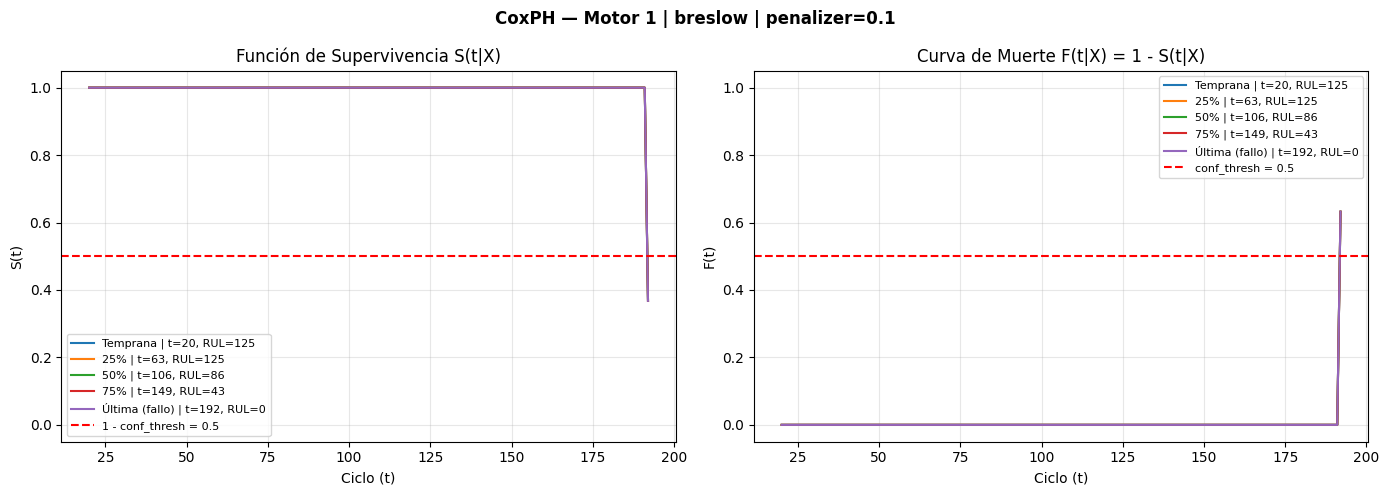


Rango S(t): [0.3679, 1.0000]
Rango F(t): [0.0000, 0.6321]
¿F(t) alcanza conf_thresh=0.5? True


In [2]:
# ── Celda 5: Curvas de supervivencia S(t) ────────────────────────────────
# Seleccionamos 5 ventanas distribuidas a lo largo de la vida del motor:
# temprana, 25%, 50%, 75% y última (justo antes del fallo)
if not model.is_fitted_:
    print("Modelo no convergió — no hay curvas que mostrar.")
else:
    n = X.shape[0]
    idx_plot = [
        0,
        n // 4,
        n // 2,
        3 * n // 4,
        n - 1,
    ]
    labels = ['Temprana', '25%', '50%', '75%', 'Última (fallo)']

    X_sel      = X[idx_plot]
    t_stop_sel = t_stop[idx_plot]
    y_rul_sel  = y_rul[idx_plot]

    sf = model.predict_survival_function(X_sel)
    dc = model.predict_death_curve(X_sel)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # S(t) — supervivencia
    ax = axes[0]
    for i, label in enumerate(labels):
        ax.plot(sf.index, sf.iloc[:, i],
                label=f'{label} | t={t_stop_sel[i]:.0f}, RUL={y_rul_sel[i]:.0f}')
    ax.axhline(1 - CONF_THRESH, color='red', linestyle='--',
               label=f'1 - conf_thresh = {1-CONF_THRESH:.1f}')
    ax.set_title('Función de Supervivencia S(t|X)')
    ax.set_xlabel('Ciclo (t)')
    ax.set_ylabel('S(t)')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # F(t) = 1 - S(t) — curva de muerte
    ax = axes[1]
    for i, label in enumerate(labels):
        ax.plot(dc.index, dc.iloc[:, i],
                label=f'{label} | t={t_stop_sel[i]:.0f}, RUL={y_rul_sel[i]:.0f}')
    ax.axhline(CONF_THRESH, color='red', linestyle='--',
               label=f'conf_thresh = {CONF_THRESH:.1f}')
    ax.set_title('Curva de Muerte F(t|X) = 1 - S(t|X)')
    ax.set_xlabel('Ciclo (t)')
    ax.set_ylabel('F(t)')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'CoxPH — Motor {MOTOR_ID} | breslow | penalizer={PENALIZER}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\nRango S(t): [{sf.values.min():.4f}, {sf.values.max():.4f}]")
    print(f"Rango F(t): [{dc.values.min():.4f}, {dc.values.max():.4f}]")
    print(f"¿F(t) alcanza conf_thresh={CONF_THRESH}? "
          f"{(dc.values >= CONF_THRESH).any()}")

Predicciones válidas: 173/173
RUL predicho rango: [0.0, 125.0]


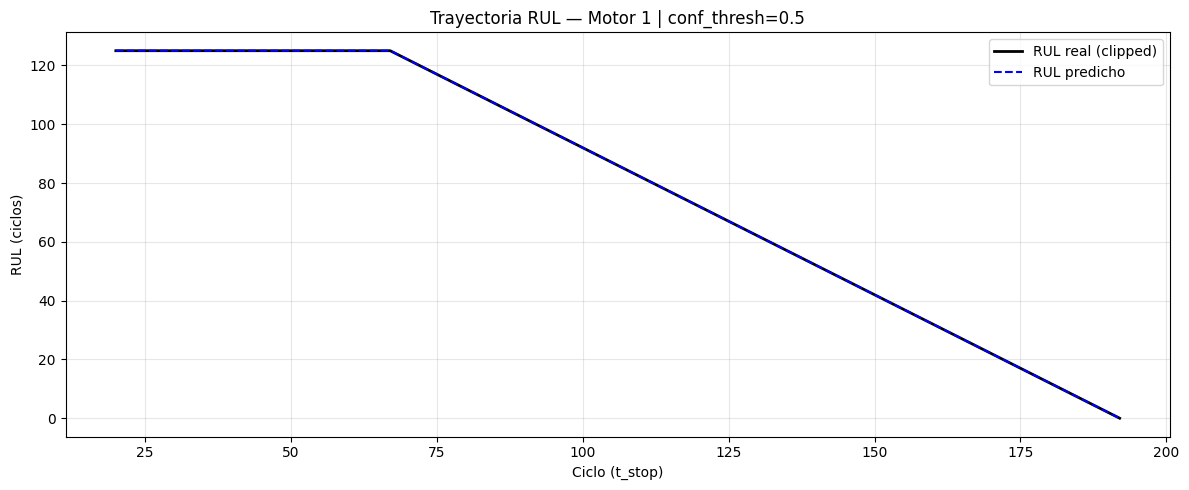

In [3]:
# ── Celda 6: Trayectoria RUL predicha vs real ─────────────────────────────
if not model.is_fitted_:
    print("Modelo no convergió — no hay predicciones que mostrar.")
else:
    rul_pred = model.predict_with_time(X, t_stop)
    valid    = ~np.isnan(rul_pred)

    print(f"Predicciones válidas: {valid.sum()}/{len(rul_pred)}")
    if valid.any():
        print(f"RUL predicho rango: [{rul_pred[valid].min():.1f}, "
              f"{rul_pred[valid].max():.1f}]")

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(t_stop, y_rul, 'k-',  linewidth=2, label='RUL real (clipped)')
    if valid.any():
        ax.plot(t_stop[valid], rul_pred[valid], 'b--',
                linewidth=1.5, label='RUL predicho')
    else:
        ax.text(0.5, 0.5, 'S(t) ≈ 1 siempre\nF(t) nunca alcanza conf_thresh\n'
                '(resultado negativo esperado)',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=12, color='red',
                bbox=dict(boxstyle='round', facecolor='lightyellow'))

    ax.set_title(f'Trayectoria RUL — Motor {MOTOR_ID} | '
                 f'conf_thresh={CONF_THRESH}')
    ax.set_xlabel('Ciclo (t_stop)')
    ax.set_ylabel('RUL (ciclos)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [4]:
# ── Celda 7: Cargar múltiples motores ─────────────────────────────────────
from src.dataset_manager import DatasetManager
from sklearn.model_selection import GroupKFold

# Usamos los primeros 20 motores de train para que sea rápido
m_train, _ = DatasetManager.split_dataset()
MOTORES_SUBSET = m_train[:20]

dfs = []
for idx in MOTORES_SUBSET:
    df = pd.read_csv(f'data/clean/data_motor_{idx}.csv')
    df.insert(0, 'unit_number', idx)
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
X_df_all = df_all.drop(columns=['RUL'])
y_df_all = df_all[['unit_number', 'time_in_cycles', 'RUL']].copy()
groups   = df_all['unit_number'].to_numpy()

print(f"Motores cargados: {df_all['unit_number'].nunique()}")
print(f"Total filas:      {len(df_all)}")
print(f"Eventos totales:  {df_all['evento'].sum()} "
      f"({100*df_all['evento'].mean():.2f}%)")

Training engines: 140
Test engines: 60
Motores cargados: 20
Total filas:      3053
Eventos totales:  9 (0.29%)


In [5]:
# ── Celda 8: Simular fold 0 del GGS ──────────────────────────────────────
PARAMS = {
    'feature_set':          'B',
    'window_size':          20,
    'n_components':         10,
    'clipping_threshold':   125,
    'confidence_threshold': 0.5,
    'baseline_estimation_method': 'breslow',
    'n_baseline_knots':     3,
    'penalizer':            0.1,
    'l1_ratio':             0.0,
}

gkf = GroupKFold(n_splits=3)
folds = list(gkf.split(X_df_all, groups=groups))
train_idx, val_idx = folds[0]

X_train_fold = X_df_all.iloc[train_idx].reset_index(drop=True)
X_val_fold   = X_df_all.iloc[val_idx].reset_index(drop=True)
y_train_fold = y_df_all.iloc[train_idx].reset_index(drop=True)
y_val_fold   = y_df_all.iloc[val_idx].reset_index(drop=True)

print(f"Fold 0:")
print(f"  Train: {X_train_fold['unit_number'].nunique()} motores, "
      f"{len(X_train_fold)} filas")
print(f"  Val:   {X_val_fold['unit_number'].nunique()} motores, "
      f"{len(X_val_fold)} filas")

# Pipeline
pipeline_params = {k: v for k, v in PARAMS.items()
                   if k in {'feature_set','window_size',
                             'n_components','clipping_threshold'}}
model_params    = {k: v for k, v in PARAMS.items()
                   if k not in pipeline_params}

pipeline_fold = RULPipeline(**pipeline_params)
X_tr, y_tr, t_tr, ev_tr, gr_tr = pipeline_fold.fit_transform(
    X_train_fold, y_train_fold)
X_vl, y_vl, t_vl, ev_vl, gr_vl = pipeline_fold.transform(
    X_val_fold, y_val_fold)

print(f"\nPipeline:")
print(f"  Train ventanas: {X_tr.shape[0]} | eventos: {ev_tr.sum()} "
      f"({100*ev_tr.mean():.2f}%)")
print(f"  Val   ventanas: {X_vl.shape[0]} | eventos: {ev_vl.sum()} "
      f"({100*ev_vl.mean():.2f}%)")

# Fit
model_fold = CoxPHModel(**model_params)
model_fold.fit(X_tr, y_tr, t_stop=t_tr, evento=ev_tr)
print(f"\nModelo fold 0: is_fitted_ = {model_fold.is_fitted_}")

Fold 0:
  Train: 13 motores, 2018 filas
  Val:   7 motores, 1035 filas

Pipeline:
  Train ventanas: 1771 | eventos: 7 (0.40%)
  Val   ventanas: 902 | eventos: 2 (0.22%)

Modelo fold 0: is_fitted_ = True


Motor de validación: 13 | 144 ventanas


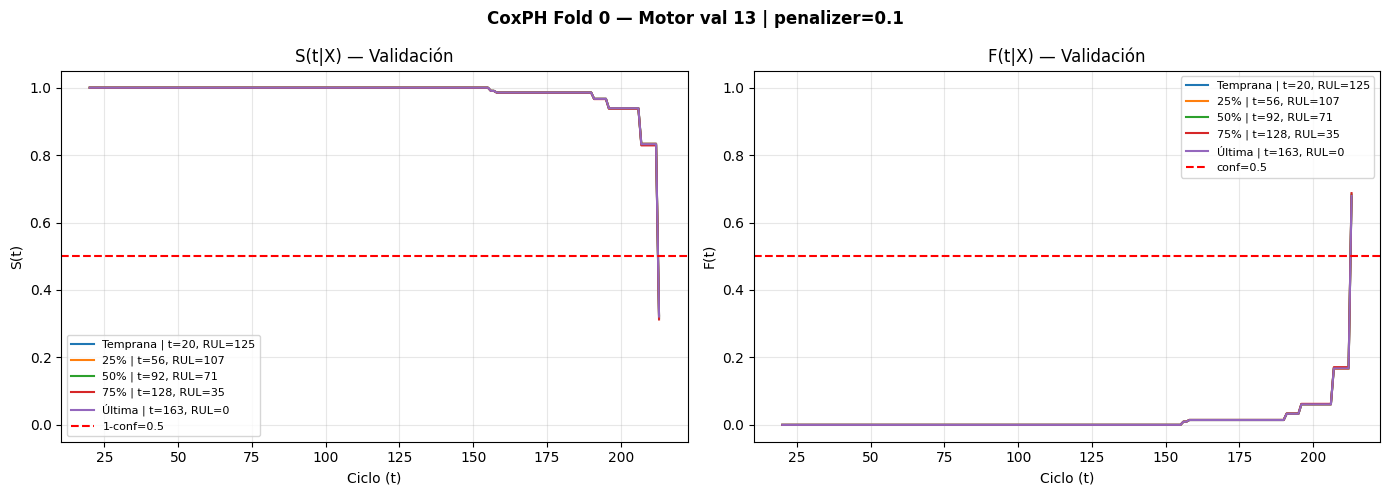


Rango S(t) val: [0.3126, 1.0000]
¿F(t) alcanza conf_thresh=0.5? True


In [6]:
# ── Celda 9: Curvas de supervivencia en validación ───────────────────────
if not model_fold.is_fitted_:
    print("Modelo no convergió en fold 0.")
else:
    # Un motor de validación al azar
    motor_val = X_val_fold['unit_number'].unique()[0]
    mask_motor = gr_vl == motor_val
    X_m   = X_vl[mask_motor]
    t_m   = t_vl[mask_motor]
    y_m   = y_vl[mask_motor]

    print(f"Motor de validación: {motor_val} | "
          f"{mask_motor.sum()} ventanas")

    n_m   = X_m.shape[0]
    idx_p = [0, n_m//4, n_m//2, 3*n_m//4, n_m-1]
    labs  = ['Temprana', '25%', '50%', '75%', 'Última']

    sf_v = model_fold.predict_survival_function(X_m[idx_p])
    dc_v = model_fold.predict_death_curve(X_m[idx_p])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for i, lab in enumerate(labs):
        t_lab = t_m[idx_p[i]]
        r_lab = y_m[idx_p[i]]
        axes[0].plot(sf_v.index, sf_v.iloc[:, i],
                     label=f'{lab} | t={t_lab:.0f}, RUL={r_lab:.0f}')
        axes[1].plot(dc_v.index, dc_v.iloc[:, i],
                     label=f'{lab} | t={t_lab:.0f}, RUL={r_lab:.0f}')

    CONF = PARAMS['confidence_threshold']
    axes[0].axhline(1-CONF, color='red', linestyle='--',
                    label=f'1-conf={1-CONF:.1f}')
    axes[1].axhline(CONF, color='red', linestyle='--',
                    label=f'conf={CONF:.1f}')

    for ax, title, ylabel in zip(
        axes,
        ['S(t|X) — Validación', 'F(t|X) — Validación'],
        ['S(t)', 'F(t)'],
    ):
        ax.set_title(title)
        ax.set_xlabel('Ciclo (t)')
        ax.set_ylabel(ylabel)
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'CoxPH Fold 0 — Motor val {motor_val} | '
                 f'penalizer={PARAMS["penalizer"]}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\nRango S(t) val: [{sf_v.values.min():.4f}, {sf_v.values.max():.4f}]")
    print(f"¿F(t) alcanza conf_thresh={CONF}? "
          f"{(dc_v.values >= CONF).any()}")

In [7]:
# ── Celda 10: Métricas del fold ───────────────────────────────────────────
from src.metrics_manager import Metrics

if not model_fold.is_fitted_:
    print("Modelo no convergió — sin métricas.")
else:
    rul_pred_vl = model_fold.predict_with_time(X_vl, t_vl)
    valid_mask  = ~np.isnan(rul_pred_vl)

    print(f"Predicciones válidas: {valid_mask.sum()}/{len(rul_pred_vl)}")

    if valid_mask.sum() > 1:
        clip = PARAMS['clipping_threshold']
        print(f"\nMétricas fold 0 (sobre {valid_mask.sum()} ventanas válidas):")
        print(f"  MAE:     {Metrics.mae(rul_pred_vl[valid_mask], y_vl[valid_mask], clip):.2f}")
        print(f"  RMSE:    {Metrics.rmse(rul_pred_vl[valid_mask], y_vl[valid_mask], clip):.2f}")
        print(f"  S-Score: {Metrics.s_score(rul_pred_vl[valid_mask], y_vl[valid_mask], clip):.2f}")
        print(f"  C-Index: {Metrics.c_index(rul_pred_vl[valid_mask], y_vl[valid_mask], clip):.4f}")
    else:
        print("\nResultado negativo confirmado: S(t) ≈ 1 siempre.")
        print("F(t) nunca alcanza el umbral — predicciones todas NaN.")
        print("Consistente con WeibullAFTModel en C-MAPSS FD001.")
        print("→ Documentar como resultado negativo en el paper.")

Predicciones válidas: 902/902

Métricas fold 0 (sobre 902 ventanas válidas):
  MAE:     25.33
  RMSE:    39.85
  S-Score: 459.50
  C-Index: 0.6599


# Hola

In [1]:
# ── Celda 1: Imports ──────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold

from src.pipeline.rul_pipeline import RULPipeline
from src.models.decision_tree import DecisionTreeModel
from src.models.random_forest import RandomForestModel
from src.models.cox_ph import CoxPHModel
from src.models.weibull_aft import WeibullAFTModel
from src.metrics_manager import Metrics

warnings.filterwarnings('ignore')
print("Imports OK")

Imports OK


In [2]:
# ── Celda 2: Cargar datos (10 motores — rápido) ───────────────────────────
from src.dataset_manager import DatasetManager

m_train, _ = DatasetManager.split_dataset()
MOTORES = m_train[:10]

dfs = []
for idx in MOTORES:
    df = pd.read_csv(f'data/clean/data_motor_{idx}.csv')
    df.insert(0, 'unit_number', idx)
    dfs.append(df)

df_all   = pd.concat(dfs, ignore_index=True)
X_df_all = df_all.drop(columns=['RUL'])
y_df_all = df_all[['unit_number', 'time_in_cycles', 'RUL']].copy()
groups   = df_all['unit_number'].to_numpy()

print(f"Motores: {df_all['unit_number'].nunique()}")
print(f"Filas:   {len(df_all)}")
print(f"Eventos: {df_all['evento'].sum()} ({100*df_all['evento'].mean():.2f}%)")

Training engines: 140
Test engines: 60
Motores: 10
Filas:   1613
Eventos: 6 (0.37%)


In [3]:
# ── Celda 3: Simular un fold manualmente ──────────────────────────────────
# Reproduce exactamente lo que hace _run_single_config internamente
PIPELINE_PARAMS = {
    'feature_set':        'B',
    'window_size':        20,
    'n_components':       10,
    'clipping_threshold': 125,
}

gkf = GroupKFold(n_splits=3)
train_idx, val_idx = list(gkf.split(X_df_all, groups=groups))[0]

X_train = X_df_all.iloc[train_idx].reset_index(drop=True)
X_val   = X_df_all.iloc[val_idx].reset_index(drop=True)
y_train = y_df_all.iloc[train_idx].reset_index(drop=True)
y_val   = y_df_all.iloc[val_idx].reset_index(drop=True)

pipeline = RULPipeline(**PIPELINE_PARAMS)
X_tr, y_rul_tr, t_stop_tr, evento_tr, groups_tr = pipeline.fit_transform(X_train, y_train)
X_vl, y_rul_vl, t_stop_vl, evento_vl, _         = pipeline.transform(X_val, y_val)

print(f"Train: {X_tr.shape[0]} ventanas | eventos: {evento_tr.sum()}")
print(f"Val:   {X_vl.shape[0]} ventanas | eventos: {evento_vl.sum()}")

Train: 982 ventanas | eventos: 3
Val:   441 ventanas | eventos: 3


In [4]:
# ── Celda 4: Test predict_with_time default en modelos de regresión ────────
# Verifica que base_model.py no rompió nada en DT y RF
print("=== Test predict_with_time default (regresión) ===\n")

for ModelClass, name in [(DecisionTreeModel, 'DT'), (RandomForestModel, 'RF')]:
    model = ModelClass()

    # fit — t_stop y evento pasados via kwargs, deben ignorarse silenciosamente
    model.fit(X_tr, y_rul_tr, t_stop=t_stop_tr, evento=evento_tr)
    assert model.is_fitted_, f"{name}: is_fitted_=False"

    # predict — comportamiento original sin cambios
    pred_original = model.predict(X_vl)
    assert not np.isnan(pred_original).any(), f"{name}: predict produce NaN"

    # predict_with_time — debe delegar a predict(X) e ignorar t_stop
    pred_with_time = model.predict_with_time(X_vl, t_stop_vl)
    np.testing.assert_array_equal(pred_original, pred_with_time)

    clip = PIPELINE_PARAMS['clipping_threshold']
    mae  = Metrics.mae(pred_with_time, y_rul_vl, clip)
    rmse = Metrics.rmse(pred_with_time, y_rul_vl, clip)
    ss   = Metrics.s_score(pred_with_time, y_rul_vl, clip)
    ci   = Metrics.c_index(pred_with_time, y_rul_vl, clip)

    print(f"{name}:")
    print(f"  predict == predict_with_time: ✓")
    print(f"  MAE={mae:.2f} | RMSE={rmse:.2f} | S-Score={ss:.2f} | C-Index={ci:.4f}")
    print()

=== Test predict_with_time default (regresión) ===

DT:
  predict == predict_with_time: ✓
  MAE=23.49 | RMSE=29.12 | S-Score=69.04 | C-Index=0.7473

RF:
  predict == predict_with_time: ✓
  MAE=20.75 | RMSE=25.83 | S-Score=29.64 | C-Index=0.7671



In [5]:
# ── Celda 5: Test _evaluate_fold con modelos de regresión ─────────────────
# Replica exactamente _evaluate_fold del GGS actualizado
from src.ggs_training_manager import _evaluate_fold

print("=== Test _evaluate_fold (regresión) ===\n")

for ModelClass, name in [(DecisionTreeModel, 'DT'), (RandomForestModel, 'RF')]:
    model = ModelClass()
    model.fit(X_tr, y_rul_tr, t_stop=t_stop_tr, evento=evento_tr)

    metrics = _evaluate_fold(model, X_vl, y_rul_vl, t_stop_vl, evento_vl)

    assert not np.isnan(metrics['MAE']),     f"{name}: MAE es NaN"
    assert not np.isnan(metrics['RMSE']),    f"{name}: RMSE es NaN"
    assert not np.isnan(metrics['S_score']), f"{name}: S_score es NaN"
    assert not np.isnan(metrics['C_index']), f"{name}: C_index es NaN"

    print(f"{name} via _evaluate_fold:")
    print(f"  MAE={metrics['MAE']:.2f} | RMSE={metrics['RMSE']:.2f} | "
          f"S-Score={metrics['S_score']:.2f} | C-Index={metrics['C_index']:.4f}")
    print()

=== Test _evaluate_fold (regresión) ===

DT via _evaluate_fold:
  MAE=23.49 | RMSE=29.12 | S-Score=69.04 | C-Index=0.7473

RF via _evaluate_fold:
  MAE=20.75 | RMSE=25.83 | S-Score=29.64 | C-Index=0.7671



In [6]:
# ── Celda 6: Test _evaluate_fold con modelos de supervivencia ─────────────
print("=== Test _evaluate_fold (supervivencia) ===\n")

for ModelClass, name, extra in [
    (CoxPHModel,      'Cox',      {'penalizer': 0.1, 'confidence_threshold': 0.5}),
    (WeibullAFTModel, 'AFT',      {'penalizer': 0.5, 'confidence_threshold': 0.5}),
]:
    model = ModelClass(**extra)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        model.fit(X_tr, y_rul_tr, t_stop=t_stop_tr, evento=evento_tr)

    print(f"{name}: is_fitted_={model.is_fitted_}")

    if model.is_fitted_:
        metrics = _evaluate_fold(model, X_vl, y_rul_vl, t_stop_vl, evento_vl)
        valid   = not np.isnan(metrics['MAE'])
        print(f"  Métricas válidas: {valid}")
        if valid:
            print(f"  MAE={metrics['MAE']:.2f} | RMSE={metrics['RMSE']:.2f} | "
                  f"S-Score={metrics['S_score']:.2f} | C-Index={metrics['C_index']:.4f}")
        else:
            print("  Predicciones NaN — resultado negativo esperado (evento rate bajo)")
    else:
        print("  No convergió — fallo silencioso correcto")
    print()

=== Test _evaluate_fold (supervivencia) ===

Cox: is_fitted_=True
  Métricas válidas: True
  MAE=25.39 | RMSE=31.30 | S-Score=56.34 | C-Index=0.8014

AFT: is_fitted_=True
  Métricas válidas: False
  Predicciones NaN — resultado negativo esperado (evento rate bajo)



In [7]:
# ── Celda 7: GGS end-to-end con DT (2 configs, 2 folds) ──────────────────
# Prueba completa del pipeline GGS con los cambios — la prueba más importante
from src.ggs_training_manager import GGSTrainingManager

print("=== GGS end-to-end con DT (debug mode) ===\n")

param_grid_debug = {
    'feature_set':       ['A', 'B'],
    'window_size':       [20],
    'n_components':      [10],
    'clipping_threshold':[125],
    'max_depth':         [5],
    'min_samples_leaf':  [5],
    'min_samples_split': [2],
    'max_features':      ['sqrt'],
}

manager = GGSTrainingManager(
    model_class=DecisionTreeModel,
    X_df=X_df_all,
    y_df=y_df_all,
    groups=groups,
)

results = manager.group_grid_search(
    param_grid=param_grid_debug,
    n_folds=2,
    silence=True,
)

df_results = manager.get_ggs_results(top_n=5)
print(df_results[['feature_set','window_size','n_components',
                   'mean_MAE','mean_RMSE','mean_S_score','mean_C_index',
                   'Success']].to_string(index=False))

# Verificaciones críticas
assert len(results) == 2,                          "FAIL: no se evaluaron 2 configs"
assert df_results['Success'].sum() > 0,            "FAIL: todas las configs fallaron"
assert not df_results['mean_MAE'].isna().all(),    "FAIL: todos los MAE son NaN"
print("\n✓ GGS end-to-end completado correctamente")

=== GGS end-to-end con DT (debug mode) ===

  🆕 New GGS session: DecisionTreeModel_016d6e92_20260512_1028
GGS: 2 total configs × 2 folds | n_jobs=1


GGS DecisionTreeModel: 100%|██████████| 2/2 [00:00<00:00,  2.95config/s]

Checkpoint removed: DecisionTreeModel_016d6e92_20260512_1028.csv
Results saved: outputs/ggs/results/DecisionTreeModel_016d6e92_20260512_1028.csv
feature_set  window_size  n_components  mean_MAE  mean_RMSE  mean_S_score  mean_C_index  Success
          A           20            10 24.495538  30.156422     77.887049      0.712562        1
          B           20            10 28.045031  37.336128    371.247126      0.670317        1

✓ GGS end-to-end completado correctamente


In [8]:
# ── Celda 8: GGS end-to-end con Cox (2 configs, 2 folds) ─────────────────
print("=== GGS end-to-end con Cox (debug mode) ===\n")

param_grid_cox_debug = {
    'feature_set':                ['A', 'B'],
    'window_size':                [20],
    'n_components':               [10],
    'clipping_threshold':         [125],
    'baseline_estimation_method': ['breslow'],
    'n_baseline_knots':           [3],
    'penalizer':                  [0.1],
    'l1_ratio':                   [0.0],
    'confidence_threshold':       [0.5],
}

manager_cox = GGSTrainingManager(
    model_class=CoxPHModel,
    X_df=X_df_all,
    y_df=y_df_all,
    groups=groups,
)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    results_cox = manager_cox.group_grid_search(
        param_grid=param_grid_cox_debug,
        n_folds=2,
        silence=True,
    )

df_cox = manager_cox.get_ggs_results(top_n=5)
print(df_cox[['feature_set','baseline_estimation_method','penalizer',
              'confidence_threshold','mean_MAE','mean_S_score',
              'mean_C_index','Success']].to_string(index=False))

assert len(results_cox) == 2, "FAIL: no se evaluaron 2 configs Cox"
print("\n✓ GGS Cox end-to-end completado — sin excepciones")
print("  (métricas NaN son resultado negativo esperado)")

=== GGS end-to-end con Cox (debug mode) ===

  🆕 New GGS session: CoxPHModel_3c781048_20260512_1028
GGS: 2 total configs × 2 folds | n_jobs=1


GGS CoxPHModel: 100%|██████████| 2/2 [00:01<00:00,  1.82config/s]

Checkpoint removed: CoxPHModel_3c781048_20260512_1028.csv
Results saved: outputs/ggs/results/CoxPHModel_3c781048_20260512_1028.csv
feature_set baseline_estimation_method  penalizer  confidence_threshold  mean_MAE  mean_S_score  mean_C_index  Success
          A                    breslow        0.1                   0.5 22.958464     82.003148      0.800457        1
          B                    breslow        0.1                   0.5 22.958464     82.003148      0.800457        1

✓ GGS Cox end-to-end completado — sin excepciones
  (métricas NaN son resultado negativo esperado)


# Yo soy


In [9]:
# ── Celda 1: Imports y setup ──────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.pipeline.rul_pipeline import RULPipeline
from src.models.cox_frailty import CoxFrailty

warnings.filterwarnings('ignore')

MOTOR_ID    = 1
WINDOW_SIZE = 20
N_COMP      = 10
CLIP        = 125
CONF_THRESH = 0.5
DISTRIBUTION = 'gamma'

print("Imports OK")

Imports OK


In [10]:
# ── Celda 2: Cargar y preparar datos ─────────────────────────────────────
df = pd.read_csv(f'data/clean/data_motor_{MOTOR_ID}.csv')
df.insert(0, 'unit_number', MOTOR_ID)

X_df = df.drop(columns=['RUL'])
y_df = df[['unit_number', 'time_in_cycles', 'RUL']].copy()

print(f"Motor {MOTOR_ID}: {len(df)} ciclos, RUL final = {df['RUL'].iloc[-1]}")
print(f"Eventos (fallos): {df['evento'].sum()}")

Motor 1: 192 ciclos, RUL final = 0
Eventos (fallos): 1


In [11]:
# ── Celda 3: Pipeline ─────────────────────────────────────────────────────
pipeline = RULPipeline(
    window_size=WINDOW_SIZE,
    clipping_threshold=CLIP,
    n_components=N_COMP,
    feature_set='B',
)
X, y_rul, t_stop, evento, groups = pipeline.fit_transform(X_df, y_df)

print(f"Pipeline output:")
print(f"  Ventanas:    {X.shape[0]}")
print(f"  Componentes: {X.shape[1]}")
print(f"  Eventos:     {evento.sum()} ({100*evento.mean():.2f}%)")
print(f"  t_stop rango: [{t_stop.min():.0f}, {t_stop.max():.0f}]")
print(f"  groups únicos: {np.unique(groups)}")

Pipeline output:
  Ventanas:    173
  Componentes: 10
  Eventos:     1 (0.58%)
  t_stop rango: [20, 192]
  groups únicos: [1]


In [12]:
# ── Celda 4: Fit CoxFrailty ───────────────────────────────────────────────
model = CoxFrailty(
    distribution=DISTRIBUTION,
    maxit=300,
    confidence_threshold=CONF_THRESH,
    clipping_threshold=CLIP,
)

# Nota: groups se pasa aquí — diferencia clave vs CoxPHModel
model.fit(X, y_rul, t_stop=t_stop, evento=evento, groups=groups)

print(f"is_fitted_:   {model.is_fitted_}")
print(f"model_name_:  {model.model_name_}")

if model.is_fitted_:
    model.print_summary()

In addition: Warning messages:
1: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
 2: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
 3: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
 Error in contr.treatment(nclass, contrasts = FALSE) : 
  not enough degrees of freedom to define contrasts
is_fitted_:   False
model_name_:  None


In [13]:
# ── Celda 5: Curvas de supervivencia S(t) y F(t) ─────────────────────────
# Nota: CoxFrailty retorna list[tuple] — distinto de CoxPHModel (DataFrame)
if not model.is_fitted_:
    print("Modelo no convergió — no hay curvas que mostrar.")
else:
    n = X.shape[0]
    idx_plot = [0, n//4, n//2, 3*n//4, n-1]
    labels   = ['Temprana', '25%', '50%', '75%', 'Última (fallo)']

    X_sel      = X[idx_plot]
    t_stop_sel = t_stop[idx_plot]
    y_rul_sel  = y_rul[idx_plot]

    sf = model.predict_survival_function(X_sel)
    dc = model.predict_death_curve(X_sel)

    if sf is None or dc is None:
        print("predict_survival_function retornó None — modelo no válido.")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for i, label in enumerate(labels):
            times_sf, probs_sf = sf[i]
            times_dc, probs_dc = dc[i]
            lbl = f'{label} | t={t_stop_sel[i]:.0f}, RUL={y_rul_sel[i]:.0f}'
            axes[0].plot(times_sf, probs_sf, label=lbl)
            axes[1].plot(times_dc, probs_dc, label=lbl)

        axes[0].axhline(1 - CONF_THRESH, color='red', linestyle='--',
                        label=f'1-conf={1-CONF_THRESH:.1f}')
        axes[1].axhline(CONF_THRESH, color='red', linestyle='--',
                        label=f'conf={CONF_THRESH:.1f}')

        for ax, title, ylabel in zip(
            axes,
            ['S(t|X) — Motor único', 'F(t|X) — Motor único'],
            ['S(t)', 'F(t)'],
        ):
            ax.set_title(title)
            ax.set_xlabel('Ciclo (t)')
            ax.set_ylabel(ylabel)
            ax.set_ylim(-0.05, 1.05)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

        plt.suptitle(
            f'CoxFrailty — Motor {MOTOR_ID} | {DISTRIBUTION} | conf={CONF_THRESH}',
            fontsize=12, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()

        # Rangos clave
        all_probs_sf = np.concatenate([p for _, p in sf])
        all_probs_dc = np.concatenate([p for _, p in dc])
        print(f"\nRango S(t): [{all_probs_sf.min():.4f}, {all_probs_sf.max():.4f}]")
        print(f"Rango F(t): [{all_probs_dc.min():.4f}, {all_probs_dc.max():.4f}]")
        print(f"¿F(t) alcanza conf_thresh={CONF_THRESH}? "
              f"{(all_probs_dc >= CONF_THRESH).any()}")

Modelo no convergió — no hay curvas que mostrar.


In [14]:
# ── Celda 6: Trayectoria RUL predicha vs real ─────────────────────────────
if not model.is_fitted_:
    print("Modelo no convergió — no hay predicciones que mostrar.")
else:
    rul_pred = model.predict_with_time(X, t_stop)
    valid    = ~np.isnan(rul_pred)

    print(f"Predicciones válidas: {valid.sum()}/{len(rul_pred)}")
    if valid.any():
        print(f"RUL predicho rango: [{rul_pred[valid].min():.1f}, "
              f"{rul_pred[valid].max():.1f}]")

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(t_stop, y_rul, 'k-', linewidth=2, label='RUL real (clipped)')

    if valid.any():
        ax.plot(t_stop[valid], rul_pred[valid], 'b--',
                linewidth=1.5, label='RUL predicho (CoxFrailty)')
    else:
        ax.text(0.5, 0.5,
                'S(t) ≈ 1 siempre\nF(t) nunca alcanza conf_thresh\n'
                '(resultado negativo esperado)',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=12, color='red',
                bbox=dict(boxstyle='round', facecolor='lightyellow'))

    ax.set_title(
        f'Trayectoria RUL — Motor {MOTOR_ID} | '
        f'CoxFrailty {DISTRIBUTION} | conf={CONF_THRESH}'
    )
    ax.set_xlabel('Ciclo (t_stop)')
    ax.set_ylabel('RUL (ciclos)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Modelo no convergió — no hay predicciones que mostrar.


In [15]:
# ── Celda 7: Cargar múltiples motores ─────────────────────────────────────
from src.dataset_manager import DatasetManager
from sklearn.model_selection import GroupKFold

m_train, _ = DatasetManager.split_dataset()
MOTORES_SUBSET = m_train[:20]

dfs = []
for idx in MOTORES_SUBSET:
    df = pd.read_csv(f'data/clean/data_motor_{idx}.csv')
    df.insert(0, 'unit_number', idx)
    dfs.append(df)

df_all   = pd.concat(dfs, ignore_index=True)
X_df_all = df_all.drop(columns=['RUL'])
y_df_all = df_all[['unit_number', 'time_in_cycles', 'RUL']].copy()
groups   = df_all['unit_number'].to_numpy()

print(f"Motores cargados: {df_all['unit_number'].nunique()}")
print(f"Total filas:      {len(df_all)}")
print(f"Eventos totales:  {df_all['evento'].sum()} "
      f"({100*df_all['evento'].mean():.2f}%)")

Training engines: 140
Test engines: 60
Motores cargados: 20
Total filas:      3053
Eventos totales:  9 (0.29%)


In [16]:
# ── Celda 8: Simular fold 0 ───────────────────────────────────────────────
PARAMS = {
    'feature_set':        'B',
    'window_size':        20,
    'n_components':       10,
    'clipping_threshold': 125,
    'distribution':       'gamma',
    'maxit':              300,
    'confidence_threshold': 0.5,
}

gkf = GroupKFold(n_splits=3)
train_idx, val_idx = list(gkf.split(X_df_all, groups=groups))[0]

X_train = X_df_all.iloc[train_idx].reset_index(drop=True)
X_val   = X_df_all.iloc[val_idx].reset_index(drop=True)
y_train = y_df_all.iloc[train_idx].reset_index(drop=True)
y_val   = y_df_all.iloc[val_idx].reset_index(drop=True)

pipeline_fold = RULPipeline(
    window_size=PARAMS['window_size'],
    clipping_threshold=PARAMS['clipping_threshold'],
    n_components=PARAMS['n_components'],
    feature_set=PARAMS['feature_set'],
)
X_tr, y_rul_tr, t_stop_tr, evento_tr, groups_tr = (
    pipeline_fold.fit_transform(X_train, y_train)
)
X_vl, y_rul_vl, t_stop_vl, evento_vl, groups_vl = (
    pipeline_fold.transform(X_val, y_val)
)

print(f"Fold 0:")
print(f"  Train: {X_train['unit_number'].nunique()} motores, "
      f"{X_tr.shape[0]} ventanas, {evento_tr.sum()} eventos "
      f"({100*evento_tr.mean():.2f}%)")
print(f"  Val:   {X_val['unit_number'].nunique()} motores, "
      f"{X_vl.shape[0]} ventanas, {evento_vl.sum()} eventos "
      f"({100*evento_vl.mean():.2f}%)")

# Fit — groups_tr pasado para el término de frailty
model_fold = CoxFrailty(
    distribution=PARAMS['distribution'],
    maxit=PARAMS['maxit'],
    confidence_threshold=PARAMS['confidence_threshold'],
    clipping_threshold=PARAMS['clipping_threshold'],
)
model_fold.fit(
    X_tr, y_rul_tr,
    t_stop=t_stop_tr,
    evento=evento_tr,
    groups=groups_tr,
)
print(f"\nModelo fold 0: is_fitted_={model_fold.is_fitted_}")

Fold 0:
  Train: 13 motores, 1771 ventanas, 7 eventos (0.40%)
  Val:   7 motores, 902 ventanas, 2 eventos (0.22%)
In addition: Warning message:
In coxpenal.fit(X, Y, istrat, offset, init = init, control, weights = weights,  :
  Inner loop failed to coverge for iterations 1 2 3 4 5 6 7

Modelo fold 0: is_fitted_=True


Motor de validación: 13 | 144 ventanas


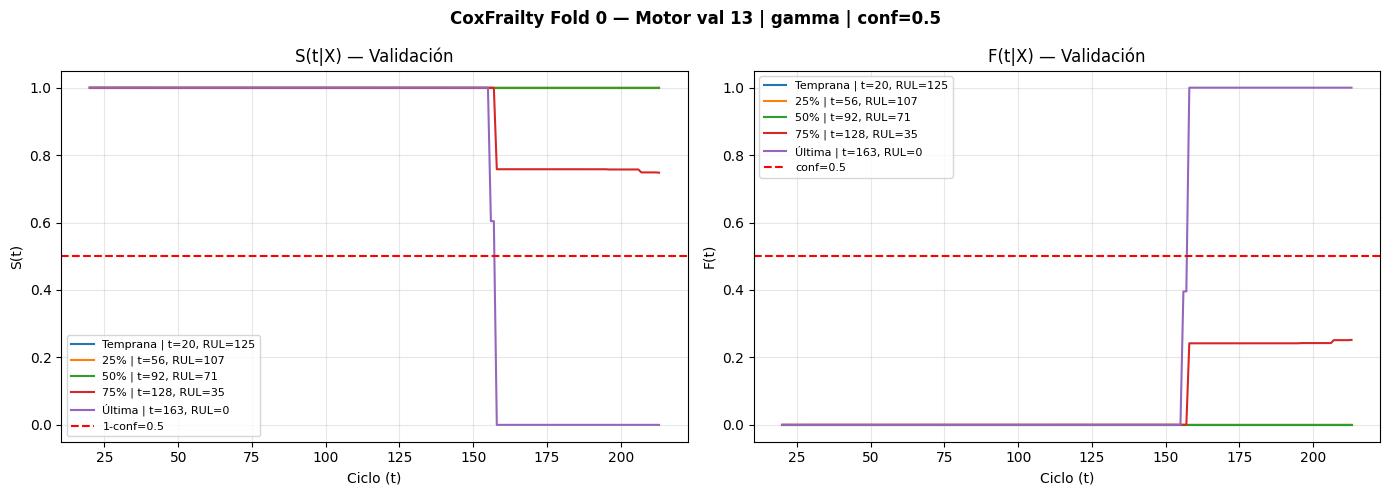


Rango F(t) val: [0.0000, 1.0000]
¿F(t) alcanza conf=0.5? True


In [17]:
# ── Celda 9: Curvas en validación ─────────────────────────────────────────
if not model_fold.is_fitted_:
    print("Modelo no convergió en fold 0.")
else:
    motor_val = X_val['unit_number'].unique()[0]
    mask      = groups_vl == motor_val
    X_m       = X_vl[mask]
    t_m       = t_stop_vl[mask]
    y_m       = y_rul_vl[mask]

    print(f"Motor de validación: {motor_val} | {mask.sum()} ventanas")

    n_m   = X_m.shape[0]
    idx_p = [0, n_m//4, n_m//2, 3*n_m//4, n_m-1]
    labs  = ['Temprana', '25%', '50%', '75%', 'Última']

    sf_v = model_fold.predict_survival_function(X_m[idx_p])
    dc_v = model_fold.predict_death_curve(X_m[idx_p])

    if sf_v is None or dc_v is None:
        print("predict_survival_function retornó None.")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for i, lab in enumerate(labs):
            times_sf, probs_sf = sf_v[i]
            times_dc, probs_dc = dc_v[i]
            lbl = f'{lab} | t={t_m[idx_p[i]]:.0f}, RUL={y_m[idx_p[i]]:.0f}'
            axes[0].plot(times_sf, probs_sf, label=lbl)
            axes[1].plot(times_dc, probs_dc, label=lbl)

        CONF = PARAMS['confidence_threshold']
        axes[0].axhline(1-CONF, color='red', linestyle='--',
                        label=f'1-conf={1-CONF:.1f}')
        axes[1].axhline(CONF, color='red', linestyle='--',
                        label=f'conf={CONF:.1f}')

        for ax, title, ylabel in zip(
            axes,
            ['S(t|X) — Validación', 'F(t|X) — Validación'],
            ['S(t)', 'F(t)'],
        ):
            ax.set_title(title)
            ax.set_xlabel('Ciclo (t)')
            ax.set_ylabel(ylabel)
            ax.set_ylim(-0.05, 1.05)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

        plt.suptitle(
            f'CoxFrailty Fold 0 — Motor val {motor_val} | '
            f'{PARAMS["distribution"]} | conf={CONF}',
            fontsize=12, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()

        all_dc = np.concatenate([p for _, p in dc_v])
        print(f"\nRango F(t) val: [{all_dc.min():.4f}, {all_dc.max():.4f}]")
        print(f"¿F(t) alcanza conf={CONF}? {(all_dc >= CONF).any()}")

In [18]:
# ── Celda 10: Métricas del fold ───────────────────────────────────────────
from src.metrics_manager import Metrics

if not model_fold.is_fitted_:
    print("Modelo no convergió — sin métricas.")
else:
    rul_pred_vl = model_fold.predict_with_time(X_vl, t_stop_vl)
    valid_mask  = ~np.isnan(rul_pred_vl)

    print(f"Predicciones válidas: {valid_mask.sum()}/{len(rul_pred_vl)}")

    if valid_mask.sum() > 1:
        clip = PARAMS['clipping_threshold']
        print(f"\nMétricas fold 0 (sobre {valid_mask.sum()} ventanas válidas):")
        print(f"  MAE:     {Metrics.mae(rul_pred_vl[valid_mask], y_rul_vl[valid_mask], clip):.2f}")
        print(f"  RMSE:    {Metrics.rmse(rul_pred_vl[valid_mask], y_rul_vl[valid_mask], clip):.2f}")
        print(f"  S-Score: {Metrics.s_score(rul_pred_vl[valid_mask], y_rul_vl[valid_mask], clip):.2f}")
        print(f"  C-Index: {Metrics.c_index(rul_pred_vl[valid_mask], y_rul_vl[valid_mask], clip):.4f}")

        # Comparación directa con CoxPH estándar — ¿aporta la frailty?
        print(f"\n  (Referencia CoxPH fold anterior: MAE≈25, S-Score≈459)")
        print(f"  ¿La frailty mejora sobre Cox estándar?")
    else:
        print("\nResultado negativo confirmado: S(t) ≈ 1 siempre.")
        print("F(t) nunca alcanza el umbral — predicciones todas NaN.")
        print("→ Consistente con CoxPHModel y WeibullAFTModel en C-MAPSS FD001.")

Predicciones válidas: 902/902

Métricas fold 0 (sobre 902 ventanas válidas):
  MAE:     24.14
  RMSE:    38.65
  S-Score: 430.31
  C-Index: 0.6693

  (Referencia CoxPH fold anterior: MAE≈25, S-Score≈459)
  ¿La frailty mejora sobre Cox estándar?
